In [1]:
# impoting libraries 
import pandas as pd
import matplotlib.pyplot as plt 
from datasets import load_dataset
import ast

# loading dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [2]:
# Pivoting the data

df_DA['Month']  = df_DA['job_posted_date'].dt.strftime('%b')
df_DA = df_DA.explode('job_skills')
df_DA
df_DA_pivoted = df_DA.pivot_table(index = "Month", columns = "job_skills", aggfunc = 'size' , fill_value=0)



# sorting months in correct order

df_DA_pivoted.reset_index(inplace=True)
df_DA_pivoted['Month_no'] = pd.to_datetime(df_DA_pivoted['Month'], format='%b').dt.month
df_DA_pivoted.sort_values('Month_no',inplace=True)
df_DA_pivoted.drop(columns= ['Month_no'])
df_DA_pivoted.set_index('Month',inplace=True)


# sorting columns in descending order

df_ordered_columns = df_DA_pivoted.sum().sort_values(ascending = False).index.to_list()
df_DA_pivoted_ordered = df_DA_pivoted[df_ordered_columns]


## Formatting Chart from : 12_Trending_Skills

Text(0.5, 0, '')

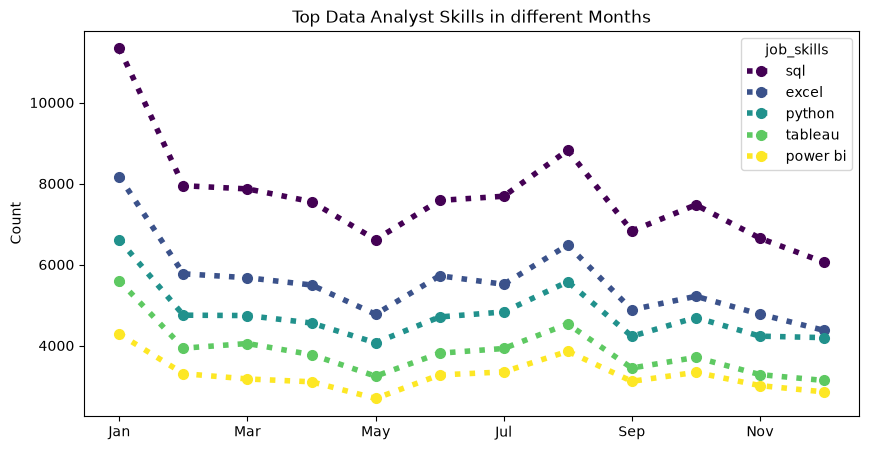

In [3]:
df_DA_pivoted_ordered.iloc[:,:5].plot(kind="line",
linewidth = 4,
linestyle = ':',
marker = 'o',
markersize = 7,
colormap = 'viridis',
figsize = (10,5)
)
plt.title("Top Data Analyst Skills in different Months")
plt.ylabel("Count")
plt.xlabel("")

## Formatting Chart from : 15_Matplotlib_Scatter_Plots

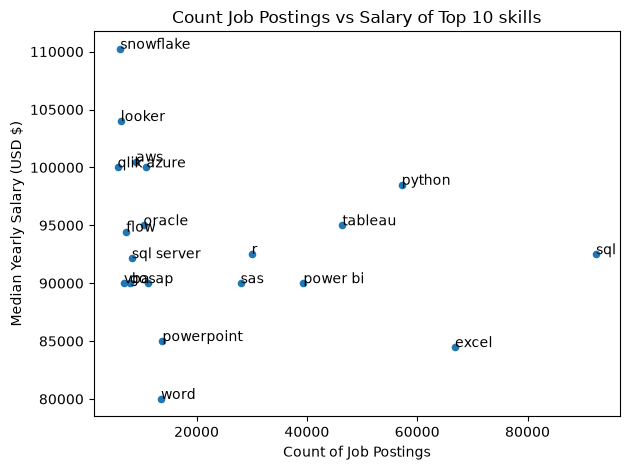

In [ ]:
# Previous Chart

df_DA = df[df['job_title_short']=='Data Analyst'].copy()
df_exploded = df_DA.explode('job_skills')
top_10 = df_exploded['job_skills'].value_counts().sort_values(ascending=False).head(10).index.to_list()
df_grouped = df_exploded.groupby('job_skills').agg(skill_count = ('job_skills','size'),median_salary = ('salary_year_avg','median'))
topn = 20
df_grouped_top_skills = df_grouped.sort_values(by='skill_count', ascending=False).head(topn)
df_grouped_top_skills.plot(kind='scatter', x= 'skill_count', y= 'median_salary' )
plt.title('Count Job Postings vs Salary of Top 10 skills')
plt.ylabel('Median Yearly Salary (USD $)')
plt.xlabel('Count of Job Postings')
for i,txt in enumerate(df_grouped_top_skills.index):
    plt.text(x=df_grouped_top_skills['skill_count'].iloc[i], y=df_grouped_top_skills['median_salary'].iloc[i],s= txt)
plt.tight_layout()


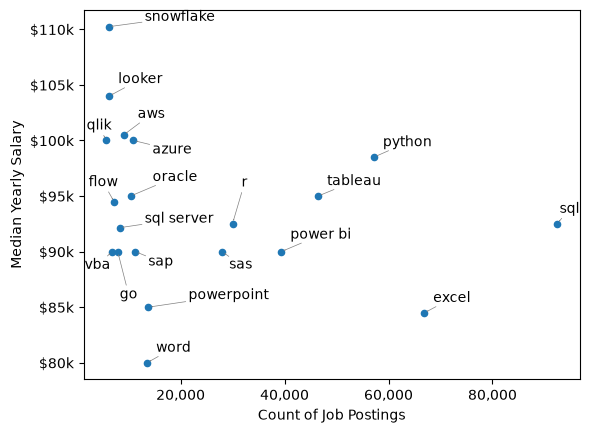

In [23]:
from adjustText import adjust_text

df_grouped_top_skills.plot(kind='scatter', x='skill_count', y='median_salary')
plt.ylabel('Median Yearly Salary')
plt.xlabel('Count of Job Postings')
texts = []
for i,title in enumerate(df_grouped_top_skills.index):
    texts.append(plt.text(x=df_grouped_top_skills['skill_count'].iloc[i], y=df_grouped_top_skills['median_salary'].iloc[i],
    s = title))

adjust_text(texts,expand=(2,2),arrowprops=dict(arrowstyle='->',color='gray',lw=0.5))

ax = plt.gca()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'{int(x):,}'))
